# Importing necessary libraries
##### Here Keras is used to build neural network, matplotlib for plotting images and graph and numpy to handel numerical data

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Loading dataset and storing them in the variables

In [2]:
(train_img, train_label), (test_img, test_label) = keras.datasets.mnist.load_data()

In [3]:
len(train_img)

60000

In [4]:
len(test_img)

10000

This means we have 60,000 training data and 10,000 test data

In [5]:
print(train_img.shape)
print(train_label.shape)

(60000, 28, 28)
(60000,)


Each sample is a 28x28 pixel image

In [6]:
train_img[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

So each image is represented as a 28x28 2D array

Text(0.5, 1.0, 'Label: 1')

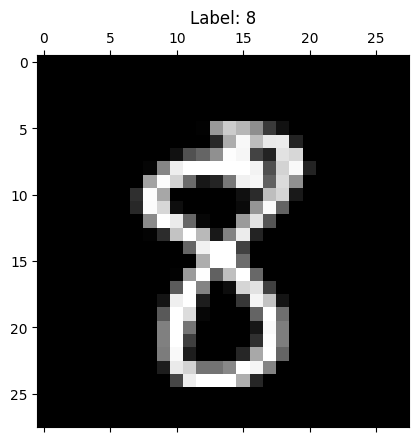

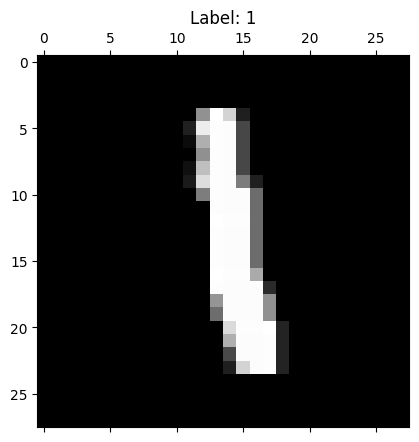

In [9]:
plt.matshow(train_img[46], cmap='gray')
plt.title(f"Label: {train_label[46]}")
plt.matshow(train_img[6], cmap='gray')
plt.title(f"Label: {train_label[6]}")

In [10]:
int(train_label[46])

8

# Normalizing Data
A Neural Network will take a lot more time if all the pixel value ranges between 0-255.
Normalizing Data means taking our data that ranges between 0-255 and compressing it so that it ranges from 0-1.
This helps the model to trains faster, more stably and accurately.

In [11]:
train_img = train_img / 255
test_img = test_img / 255

# Flattening The data
Each image is flattened from 28x28 2D array to 784 length 1D array so that it can be used my neural network as input

In [13]:
train_img = train_img.reshape(-1,784)
test_img = test_img.reshape(-1,784)

In [14]:
train_img[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

Hence converted into 1D array

# Building the Model
Using Activation Function Relu that helps model to learn features

In [19]:
model = keras.Sequential([
    keras.layers.Dense(180, activation= 'relu', input_shape=(784,)),
    keras.layers.Dense(64, activation= 'relu'),
    keras.layers.Dense(10, activation= 'softmax')
])

# Compile the Model
Optimizer: It decides how the model learns from mistakes  
Loss: measures error  
Metrics: used to measure performance in human-understandable form


In [21]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Training the Model
Training the model on the training dataset  
Epoch is the number of complete pass through the entire dataset

In [22]:
fit_result = model.fit(train_img, train_label, epochs=10, batch_size=64, )

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9244 - loss: 0.2600
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9682 - loss: 0.1062
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9784 - loss: 0.0720
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9842 - loss: 0.0512
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9870 - loss: 0.0407
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9900 - loss: 0.0306
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9916 - loss: 0.0249
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9926 - loss: 0.0221
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9938 - loss: 0.0187
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9953 - loss: 0.0148


# Accuracy Graph

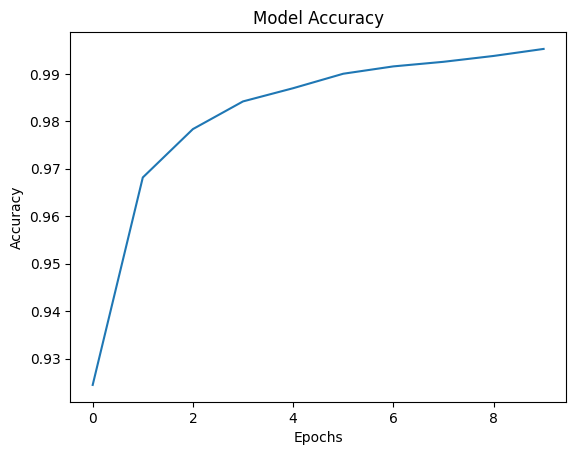

In [23]:
plt.plot(fit_result.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

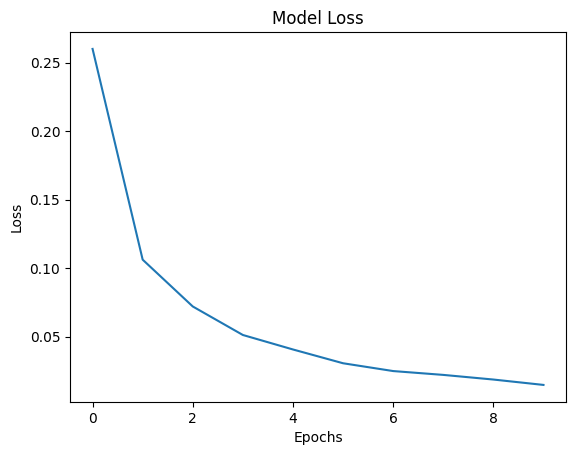

In [24]:
plt.plot(fit_result.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Testing the Model on Unseen Data

In [27]:
test_loss, test_acc = model.evaluate(test_img, test_label)
print("Test Accuracy:", test_acc)
model.save("digit_model.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9787 - loss: 0.0847
Test Accuracy: 0.9786999821662903


# Making Predictions Using the Trained Model
Prediction is done and compared with actual answers

In [36]:
pred = model.predict(test_img[:10])
print("Prediction:", np.argmax(pred[:10], axis = 1))
print("Actual:", test_label[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Prediction: [7 2 1 0 4 1 4 9 5 9]
Actual: [7 2 1 0 4 1 4 9 5 9]
